In [ ]:
# Installs
%pip install sentence_transformers

In [ ]:
# Imports
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

import torch
import torch.nn as nn
from torch.utils import data
import torch.optim as optim

from sentence_transformers import SentenceTransformer
from transformers import BertModel, BertTokenizer # для получения эмбеддингов с помощью BERT
from transformers import GPT2Tokenizer, GPT2Model # для получения эмбеддингов с помощью GPT2
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Скачиваем данные с kaggle
full_data_path = kagglehub.dataset_download("bayes2003/emails-for-spam-or-ham-classification-trec-2006")

print("Path to dataset files:", full_data_path)

Path to dataset files: /root/.cache/kagglehub/datasets/bayes2003/emails-for-spam-or-ham-classification-trec-2006/versions/1


In [ ]:
# Загрузка данных (возьмем первые 1000 строк)
FileName  = 'email_text.csv'
full_data = pd.read_csv(os.path.join(full_data_path, FileName), nrows=1000)

full_data.head()

,label,text
0,0,the mailing list i queried about a few weeks a...
1,1,luxury watches buy your own rolex for only esc...
2,1,academic qualifications available from prestig...
3,0,greetings all this is to verify your subscript...
4,1,try chauncey may conferred the luscious not co...


In [ ]:
full_data.shape

(1000, 2)

In [ ]:
# Проверка наличия null-значений
full_data.isna().sum()

,0
label,0
text,0


,count
label,
0,652
1,348


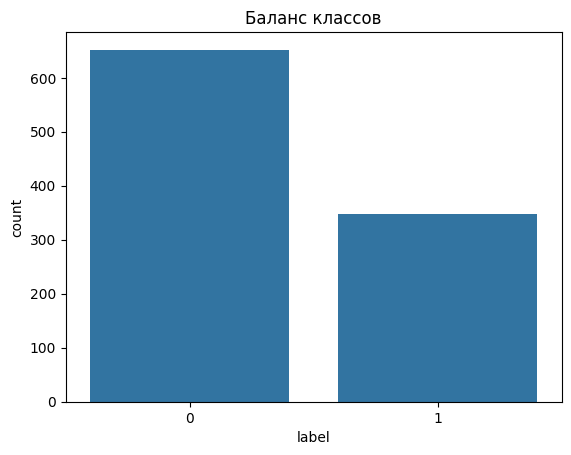

In [ ]:
# Проверка баланса классов
balance_count = full_data.label.value_counts()
display(balance_count)

sns.barplot(balance_count)
plt.title('Баланс классов')
plt.show();

In [ ]:
# Предобработка данных
def text_cleaner(text):

  # преобразовани текста в нижний регистр
  text = text.lower()

  # удаление лишних пробелов
  text = re.sub(r'\s+', ' ', text)

  # преобразование сокращений
  text = re.sub(r"won't", "will not", text)
  text = re.sub(r"can't", "cannot", text)
  text = re.sub(r"n't", " not", text)
  text = re.sub(r"'ve", " have", text)
  text = re.sub(r"'ll", " will", text)
  text = re.sub(r"'d", " would", text)
  text = re.sub(r"'re", " are", text)
  text = re.sub(r"'s", " is", text)
  text = re.sub(r"'m", " am", text)

  # удаление знаков препинания
  text = re.sub(r'[^\w\s]', '', text)

  # удаление стоп-слов
  stop_words = set(stopwords.words('english'))
  tokens = word_tokenize(text)
  filtered_text = [word for word in tokens if word not in stop_words]

  # лематизация текста
  lemmatizer = WordNetLemmatizer()
  lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_text]

  # объединение лемматизированных токенов в текст
  cleaned_text = ' '.join(lemmatized_text)

  return cleaned_text

full_data['cleaned_text'] = full_data['text'].map(lambda email: text_cleaner(email))

# Пример текста электронных сообщений до и после обработки
full_data[['text', 'cleaned_text']].head()

,text,cleaned_text
0,the mailing list i queried about a few weeks a...,mailing list queried week ago running also set...
1,luxury watches buy your own rolex for only esc...,luxury watch buy rolex escapenumber rolex cart...
2,academic qualifications available from prestig...,academic qualification available prestigious n...
3,greetings all this is to verify your subscript...,greeting verify subscription planescapenumber ...
4,try chauncey may conferred the luscious not co...,try chauncey may conferred luscious continued ...


# BERT

In [ ]:
# Загрузка предобученной модели BERT
model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
BERT_model = SentenceTransformer(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Векторные представления для предобработанных текстовых данных
embeddings = BERT_model.encode(full_data['cleaned_text'].tolist())
embeddings.shape

(1000, 768)

In [ ]:
# Разделение данных
RS = 42
X_train, X_test, y_train, y_test = train_test_split(embeddings, full_data['label'], test_size=0.2, random_state=RS)

In [ ]:
# Преобразование данных в тензоры pt
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Создание датасетов
train_dataset = data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = data.TensorDataset(X_test_tensor, y_test_tensor)

# Создание даталоадеров
BATCH_SIZE = 32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [ ]:
# Определение модели
class SPAMclassifier(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, dropout= 0.9):
    super().__init__()
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.fc2 = nn.Linear(hidden_size, output_size)
    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()
    self.dropout = nn.Dropout(dropout)
  def forward(self, x):
    out = self.fc1(x)
    out = self.relu(out)
    out = self.dropout(out)
    out = self.fc2(out)
    out = self.sigmoid(out)
    return out

In [ ]:
# Параметры модели
input_size = embeddings.shape[1]
hidden_size = 256
output_size = 1
EPOCH = 10

# Создание модели
model = SPAMclassifier(input_size, hidden_size, output_size)

# Определение функции потерь и оптимизатора
criterion = nn.BCELoss() # используем Binary Cross Entropy loss
optimizer = optim.Adam(model.parameters())

In [ ]:
def train(model, optimizer, criterion, train_loader, test_loader, epochs):
  # переменные списков для хранения значений потерь и точности на обучающей и тестовой выборках
  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []

  # Обучение модели
  for epoch in tqdm(range(epochs)):
    model.train()
    train_loss = 0.0
    train_acc = 0
    for inputs, labels in train_loader:
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, labels.unsqueeze(1))
      loss.backward()
      optimizer.step()
      train_loss += loss.item()

      # Вычисление точности на обучающей выборке
      predicted_train = torch.round(outputs)
      correct = (predicted_train == labels.unsqueeze(1)).float()
      acc = correct.sum() / len(correct)
      train_acc += acc.item()

    # Сохранение значений потерь и точности на обучающей выборке
    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(train_acc / len(train_loader))

    # Оценка модели на тестовой выборке
    model.eval()
    test_loss = 0.0
    test_acc = 0

    with torch.no_grad():
      for inputs, labels in test_loader:
        outputs = model(inputs)
        loss = criterion(outputs, labels.unsqueeze(1))
        test_loss += loss.item()

        # Вычисление точности на тестовой выборке
        predicted_test = torch.round(outputs)
        correct = (predicted_test == labels.unsqueeze(1)).float()
        acc = correct.sum() / len(correct)
        test_acc += acc.item()

    # Сохранение значений точности и потерь на тестовой выборке
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_acc / len(test_loader))

    print(f'Epoch {epoch+1}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Test Loss: {test_losses[-1]}, Test Accuracy: {test_accuracies[-1]}')

  return train_losses, train_accuracies, test_losses, test_accuracies

train_losses, train_accuracies, test_losses, test_accuracies = train(model, optimizer, criterion, train_loader, test_loader, EPOCH)

 20%|██        | 2/10 [00:00<00:00, 13.02it/s]

Epoch 1, Train Loss: 0.6140056228637696, Train Accuracy: 0.65375, Test Loss: 0.4810308814048767, Test Accuracy: 0.8125
Epoch 2, Train Loss: 0.5020093393325805, Train Accuracy: 0.76125, Test Loss: 0.37389878715787617, Test Accuracy: 0.8839285714285714
Epoch 3, Train Loss: 0.426336322426796, Train Accuracy: 0.80875, Test Loss: 0.3096953864608492, Test Accuracy: 0.8928571428571429


 60%|██████    | 6/10 [00:00<00:00, 14.10it/s]

Epoch 4, Train Loss: 0.3809233021736145, Train Accuracy: 0.84, Test Loss: 0.2642118973391397, Test Accuracy: 0.8928571428571429
Epoch 5, Train Loss: 0.3549393320083618, Train Accuracy: 0.835, Test Loss: 0.23387167070593154, Test Accuracy: 0.9241071428571429
Epoch 6, Train Loss: 0.3137434220314026, Train Accuracy: 0.86625, Test Loss: 0.2136041181428092, Test Accuracy: 0.9241071428571429
Epoch 7, Train Loss: 0.2974065715074539, Train Accuracy: 0.87625, Test Loss: 0.2025520301290921, Test Accuracy: 0.9375


100%|██████████| 10/10 [00:00<00:00, 14.46it/s]

Epoch 8, Train Loss: 0.2522455608844757, Train Accuracy: 0.89375, Test Loss: 0.19607138527291162, Test Accuracy: 0.9375
Epoch 9, Train Loss: 0.2484109017252922, Train Accuracy: 0.9025, Test Loss: 0.18016063102654048, Test Accuracy: 0.9464285714285714
Epoch 10, Train Loss: 0.21527716040611267, Train Accuracy: 0.9225, Test Loss: 0.170638878430639, Test Accuracy: 0.9464285714285714


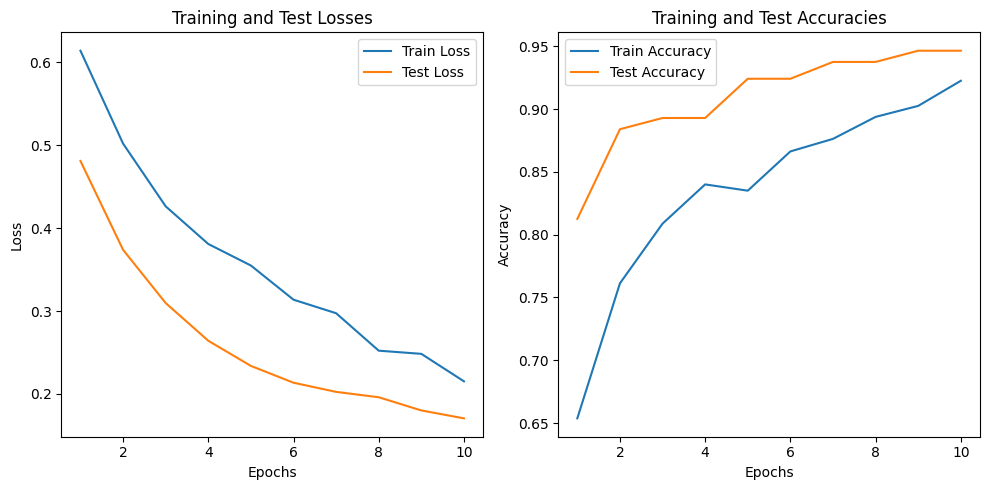

In [ ]:
# Построение графиков
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCH + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCH + 1), test_losses, label="Test Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Losses')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCH + 1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, EPOCH + 1), test_accuracies, label="Test Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracies')
plt.legend()

plt.tight_layout()
plt.show();

In [ ]:
# Расчет метрик Accuracy и F1-score для тестовой выборки
probabilities = model(X_test_tensor)
predictions = torch.round(probabilities.data).squeeze(1)

accuracy = accuracy_score(predictions, y_test_tensor)
f1 = f1_score(predictions, y_test_tensor)

print(f'Accuracy: {accuracy:.2f}\nF1-score:{f1:.2f}')

Accuracy: 0.97
F1-score:0.95


# GPT

In [ ]:
# Загрузка токенизатора и предобученной модели GPT2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
tokenizer.pad_token = tokenizer.eos_token
GPT2model = GPT2Model.from_pretrained('gpt2')

GPT2model.to(device)

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

In [ ]:
# Токенизация и паддинг. Получение словаря закодированных последовательностей текстов
encoded_captions = tokenizer(
    full_data['cleaned_text'].tolist(),
    return_tensors='pt',
    padding=True,
    truncation=True
)

# Перенос значений словаря на используемое устройство
encoded_captions =  {key: value.to(device) for key, value in encoded_captions.items()}

In [ ]:
# Получение эмбеддингов

all_sentence_embeddings = [] # список для хранения эмбеддингов
batch_size = 4 # небходим для распределения нагрузки на GPU

# Разделим данные на батчи и передадим их в модель
for i in range(0, len(encoded_captions['input_ids']), batch_size):
    batch_input_ids = encoded_captions['input_ids'][i:i+batch_size].to(device)
    batch_attention_mask = encoded_captions['attention_mask'][i:i+batch_size].to(device)

    # Передаем батчи в модель
    with torch.no_grad():
        batch_outputs = GPT2model(batch_input_ids)

    # Извлекаем embeddings для каждого батча
    word_embeddings = batch_outputs.last_hidden_state

    # Mask для игнорирования padding tokens
    masked_word_embeddings = word_embeddings * batch_attention_mask.unsqueeze(-1).float()

    # Объединение сумм с учётом токенов без non-padding
    sentence_embeddings = masked_word_embeddings.sum(dim=1)

    # Нормализация по количеству токенов без non-padding
    sentence_embeddings /= batch_attention_mask.sum(dim=1, keepdim=True).float()

    # Добавляем embeddings батча в список
    all_sentence_embeddings.append(sentence_embeddings)

# Собираем все embeddings батчей в один список
all_sentence_embeddings = torch.cat(all_sentence_embeddings, dim=0)

all_sentence_embeddings

tensor([[-0.0397, -0.1098, -0.3414,  ..., -0.2921,  0.1893,  0.3437],
        [ 0.1577, -0.1613, -0.2698,  ..., -0.0442,  0.1162,  0.2002],
        [ 0.1049,  0.0737, -0.5971,  ...,  0.2132,  0.3318,  0.0623],
        ...,
        [ 0.0898, -0.2799, -0.5587,  ...,  0.0197,  0.2609, -0.1169],
        [ 0.0719, -0.2068, -0.6526,  ...,  0.0997,  0.1555,  0.0533],
        [-0.0061, -0.2416, -0.5308,  ...,  0.0801,  0.2188,  0.0515]],
       device='cuda:0')

In [ ]:
# Разделение данных и создание даталоадера

X_train, X_test, y_train, y_test = train_test_split(
    all_sentence_embeddings,
    full_data['label'],
    test_size=0.2, random_state=RS
    )

# Преобразование данных в тензоры pt
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Создание датасетов
train_dataset = data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = data.TensorDataset(X_test_tensor, y_test_tensor)

# Создание даталоадеров
BATCH_SIZE = 32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH_SIZE)

<ipython-input-22-ef8a6f2f85f3>:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
<ipython-input-22-ef8a6f2f85f3>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)


In [ ]:
# Объявим модель, используя тот же класс, что и при использовании эмбеддингов BERT

# Параметры модели
input_size = all_sentence_embeddings.shape[1]
hidden_size = 256
output_size = 1

# Создание модели
model = SPAMclassifier(input_size, hidden_size, output_size)
model = model.to(device)

# Определение функции потерь и оптимизатора
criterion = nn.BCELoss() # используем Binary Cross Entropy loss
optimizer = optim.Adam(model.parameters())

In [ ]:
# Для обучения используем ту же функцию, переписав ее под вычисления на GPU

def train(model, optimizer, criterion, train_loader, test_loader, epochs):
  # переменные списков для хранения значений потерь и точности на обучающей и тестовой выборках
  train_losses = []
  train_accuracies = []
  test_losses = []
  test_accuracies = []

  # Обучение модели
  for epoch in tqdm(range(epochs)):
    model.train()
    train_loss = 0.0
    train_acc = 0
    for inputs, labels in train_loader:
      optimizer.zero_grad()
      inputs = inputs.to(device)  # переносим данные на устройство
      labels = labels.to(device)  # переносим данные на устройство
      outputs = model(inputs)
      loss = criterion(outputs, labels.unsqueeze(1))
      loss.backward()
      optimizer.step()
      train_loss += loss.item()

      # Вычисление точности на обучающей выборке
      predicted_train = torch.round(outputs)
      correct = (predicted_train == labels.unsqueeze(1)).float()
      acc = correct.sum() / len(correct)
      train_acc += acc.item()

    # Сохранение значений потерь и точности на обучающей выборке
    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(train_acc / len(train_loader))

    # Оценка модели на тестовой выборке
    model.eval()
    test_loss = 0.0
    test_acc = 0

    with torch.no_grad():
      for inputs, labels in test_loader:
        inputs = inputs.to(device)  # переносим данные на устройство
        labels = labels.to(device)  # переносим данные на устройство
        outputs = model(inputs)
        loss = criterion(outputs, labels.unsqueeze(1))
        test_loss += loss.item()

        # Вычисление точности на тестовой выборке
        predicted_test = torch.round(outputs)
        correct = (predicted_test == labels.unsqueeze(1)).float()
        acc = correct.sum() / len(correct)
        test_acc += acc.item()

    # Сохранение значений точности и потерь на тестовой выборке
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_acc / len(test_loader))

    print(f'Epoch {epoch+1}, Train Loss: {train_losses[-1]}, Train Accuracy: {train_accuracies[-1]}, Test Loss: {test_losses[-1]}, Test Accuracy: {test_accuracies[-1]}')

  return train_losses, train_accuracies, test_losses, test_accuracies

train_losses, train_accuracies, test_losses, test_accuracies = train(model, optimizer, criterion, train_loader, test_loader, EPOCH)

 30%|███       | 3/10 [00:00<00:00, 12.18it/s]

Epoch 1, Train Loss: 1.5855427289009094, Train Accuracy: 0.55875, Test Loss: 0.4635874501296452, Test Accuracy: 0.7589285714285714
Epoch 2, Train Loss: 0.7163282573223114, Train Accuracy: 0.64875, Test Loss: 0.4811670354434422, Test Accuracy: 0.9330357142857143
Epoch 3, Train Loss: 0.5538196384906768, Train Accuracy: 0.70875, Test Loss: 0.3957985384123666, Test Accuracy: 0.8303571428571429
Epoch 4, Train Loss: 0.5259678554534912, Train Accuracy: 0.74, Test Loss: 0.3667414741856711, Test Accuracy: 0.9285714285714286


 70%|███████   | 7/10 [00:00<00:00, 16.33it/s]

Epoch 5, Train Loss: 0.488946225643158, Train Accuracy: 0.77375, Test Loss: 0.3265328194413866, Test Accuracy: 0.9464285714285714
Epoch 6, Train Loss: 0.46135727524757386, Train Accuracy: 0.785, Test Loss: 0.28604285418987274, Test Accuracy: 0.9464285714285714
Epoch 7, Train Loss: 0.4495006513595581, Train Accuracy: 0.77875, Test Loss: 0.2738426412854876, Test Accuracy: 0.9508928571428571
Epoch 8, Train Loss: 0.4124532055854797, Train Accuracy: 0.8275, Test Loss: 0.2504387902362006, Test Accuracy: 0.9508928571428571


100%|██████████| 10/10 [00:00<00:00, 15.41it/s]

Epoch 9, Train Loss: 0.39902565360069275, Train Accuracy: 0.8225, Test Loss: 0.228583140032632, Test Accuracy: 0.9553571428571429
Epoch 10, Train Loss: 0.37386149644851685, Train Accuracy: 0.82625, Test Loss: 0.2030352290187563, Test Accuracy: 0.9642857142857143


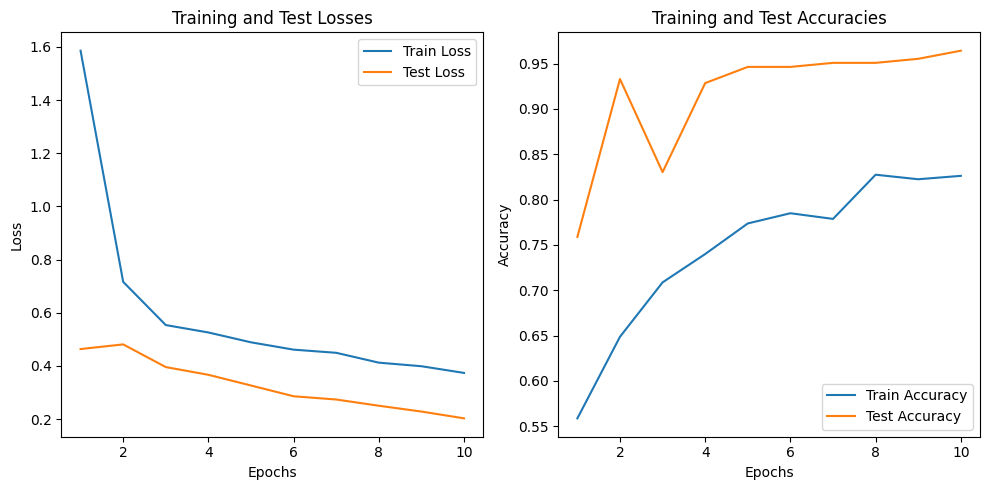

In [ ]:
# Построение графиков
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCH+1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCH+1), test_losses, label="Test Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Losses')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCH+1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, EPOCH+1), test_accuracies, label="Test Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracies')
plt.legend()

plt.tight_layout()
plt.show();

In [ ]:
# Расчет метрик Accuracy и F1-score для тестовой выборки
probabilities = model(X_test_tensor).cpu()

predictions = torch.round(probabilities.data).squeeze(1)

accuracy = accuracy_score(predictions, y_test_tensor)
f1 = f1_score(predictions, y_test_tensor)

print(f'Accuracy: {accuracy:.2f}\nF1-score:{f1:.2f}')

Accuracy: 0.96
F1-score:0.93


В данном случае модель, с использованием эмбеддингов на основе BERT показала лучшие результаты чем GPT2. Думаю это связано с тем, что, в данной задаче, не требуется генерация текста и возможности GPT избыточны, в то же время с задачами классификации BERT справляется эффективнее. Так же замечено, что GPT потребовало больше вычислительной мощности и времени.